In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 28.2 MB/s eta 0:00:00


In [23]:
import pandas as pd
import re
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('/content/drive/MyDrive/Sentiment_Data.csv', encoding='ISO-8859-1')

In [6]:
#slang dictionary
slang_dict = {
    "u": "you", "ur": "your", "lol": "laugh out loud", "omg": "oh my god",
    "idk": "I don't know", "btw": "by the way", "gr8": "great",
    "thx": "thanks", "pls": "please", "imo": "in my opinion"
}

In [26]:
# Expand
def expand_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])

In [27]:
# remove the emoji
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

In [9]:
def clean_and_normalize(text):
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = remove_emojis(text)
    text = expand_slang(text)
    text = re.sub(r"[^\w\s.,!?]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [30]:
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_and_normalize)

In [31]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
tfidf_features = tfidf_vectorizer.fit_transform(df['Clean_Tweet'])

In [32]:
df['tweet_length'] = df['Clean_Tweet'].apply(len)
df['word_count'] = df['Clean_Tweet'].apply(lambda x: len(x.split()))
df['excl_count'] = df['Clean_Tweet'].apply(lambda x: x.count('!'))
df['upper_count'] = df['Clean_Tweet'].apply(lambda x: sum(1 for w in x.split() if w.isupper()))


In [33]:
df[['Clean_Tweet', 'tweet_length', 'word_count', 'excl_count', 'upper_count', 'Sentiment']].head()


,Clean_Tweet,tweet_length,word_count,excl_count,upper_count,Sentiment
0,Happy Anniversary!!!....The Day the FreeDUMB D...,89,14,3,0,Mild_Pos
1,Happy Anniversary!!!....The Day the FreeDUMB D...,89,14,3,0,Mild_Pos
2,Happy Anniversary!!!....The Day the FreeDUMB D...,89,14,3,0,Mild_Pos
3,Happy Anniversary!!!....The Day the FreeDUMB D...,89,14,3,0,Mild_Pos
4,Happy Anniversary!!!....The Day the FreeDUMB D...,89,14,3,0,Mild_Pos


In [16]:
#taking random sample of the data
sample_df = df.sample(n=10000, random_state=42)


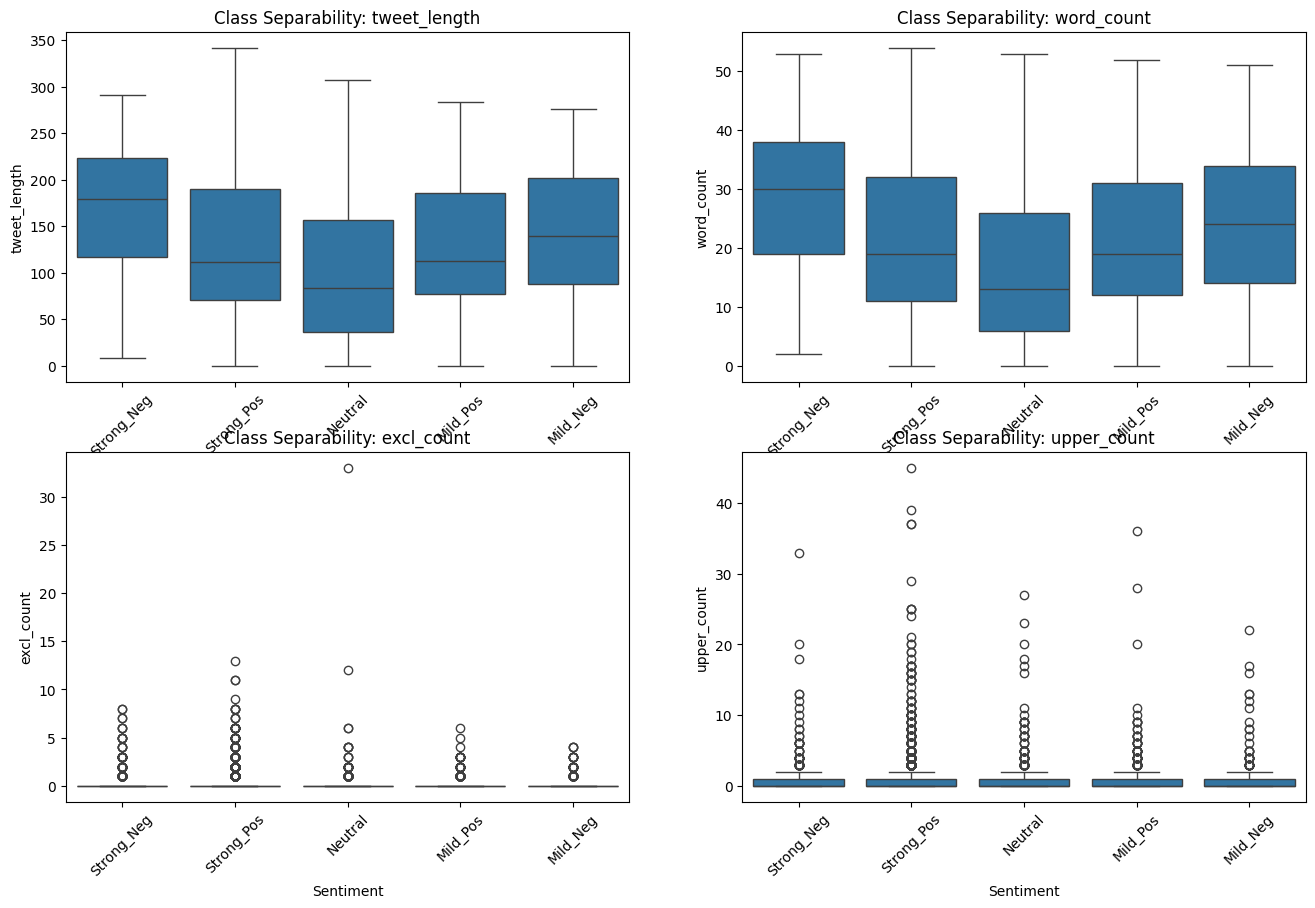

In [17]:
plt.figure(figsize=(16, 10))
for i, feature in enumerate(['tweet_length', 'word_count', 'excl_count', 'upper_count'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=sample_df, x='Sentiment', y=feature)
    plt.title(f'Class Separability: {feature}')
    plt.xticks(rotation=45)